# Focus Pocus - dashboard draft

Reads only `focus-pocus-data.csv` (from `build_dataset.py`). Panels B, D, E are
native dabest `mean_diff` Cumming plots by weekday (hours/day vs 8h, hours/session
vs a 45-min focus block, self-rating vs the app's measured efficiency). A and C are
descriptive; F is reserved. Run on the **Python (dabest)** kernel.


In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, dabest
import matplotlib
import matplotlib.pyplot as plt
from datetime import datetime

HERE = r"C:\Users\user\Documents\GitHub\Portfolio\tools\focus-pocus"
NAVY="#1E3A6E"; GOLD="#C29B2E"; PBLUE="#7FA8D0"; PGOLD="#E0C98A"
INK="#1C2433"; MUTED="#8A8272"; GRID="#ECE7DA"; AXISC="#C9C0AD"; GREY="#9AA0A6"; BG="#FFFFFF"
plt.rcParams.update({"font.family":"DejaVu Sans","figure.facecolor":BG,"axes.facecolor":BG,
    "savefig.facecolor":BG,"text.color":INK,"axes.labelcolor":INK})
WK=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
POMODORO_H=45/60

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 17.33it/s]

Numba compilation complete!


In [2]:
df=pd.read_csv(os.path.join(HERE,"focus-pocus-data.csv"))
maxs=df.filter(regex=r"^s\d+_start").shape[1]
recs=[]
for _,r in df.iterrows():
    for i in range(1,maxs+1):
        if pd.isna(r.get(f"s{i}_focus_min")): continue
        recs.append(dict(date=r["date"],day=r["day"],focus_hours=r[f"s{i}_focus_min"]/60,
                         self_eff=r[f"s{i}_self_eff"],meas_eff=r[f"s{i}_meas_eff"]))
L=pd.DataFrame(recs)
days=df["date"].tolist(); day_dt=[datetime.strptime(d,"%Y-%m-%d") for d in days]
day_hours=df["day_hours"].to_numpy()

best_s=best_e=s0=0
for i in range(1,len(day_dt)):
    if (day_dt[i]-day_dt[i-1]).days==1:
        if i-s0>best_e-best_s: best_s,best_e=s0,i
    else: s0=i
streak=list(range(best_s,best_e+1))

In [3]:
def clean(ax):
    for sp in ("top","right"): ax.spines[sp].set_visible(False)
    ax.spines["left"].set_color(AXISC); ax.spines["bottom"].set_color(AXISC)
    ax.tick_params(length=0,colors=MUTED); ax.set_axisbelow(True)
    ax.yaxis.grid(True,color=GRID,lw=1); ax.xaxis.grid(False)

def dabest_panel(ax, ctrl, ctrl_vals, group_col, val_col, frame, color, raw_label, contrast_label, title):
    present=[w for w in WK if (frame[group_col]==w).any()]
    rows=[(ctrl,v) for v in ctrl_vals]+[(w,v) for w in present for v in frame.loc[frame[group_col]==w,val_col]]
    long=pd.DataFrame(rows,columns=["g","y"])
    db=dabest.load(long, idx=(ctrl,)+tuple(present), x="g", y="y")
    pal={ctrl:MUTED}; pal.update({w:color for w in present})
    db.mean_diff.plot(ax=ax, raw_marker_size=4, custom_palette=pal,
                      raw_label=raw_label, contrast_label=contrast_label,
                      title=title, fontsize_title=13,
                      fontsize_rawylabel=11, fontsize_contrastylabel=11,
                      fontsize_rawxlabel=8, fontsize_contrastxlabel=7)
    return db

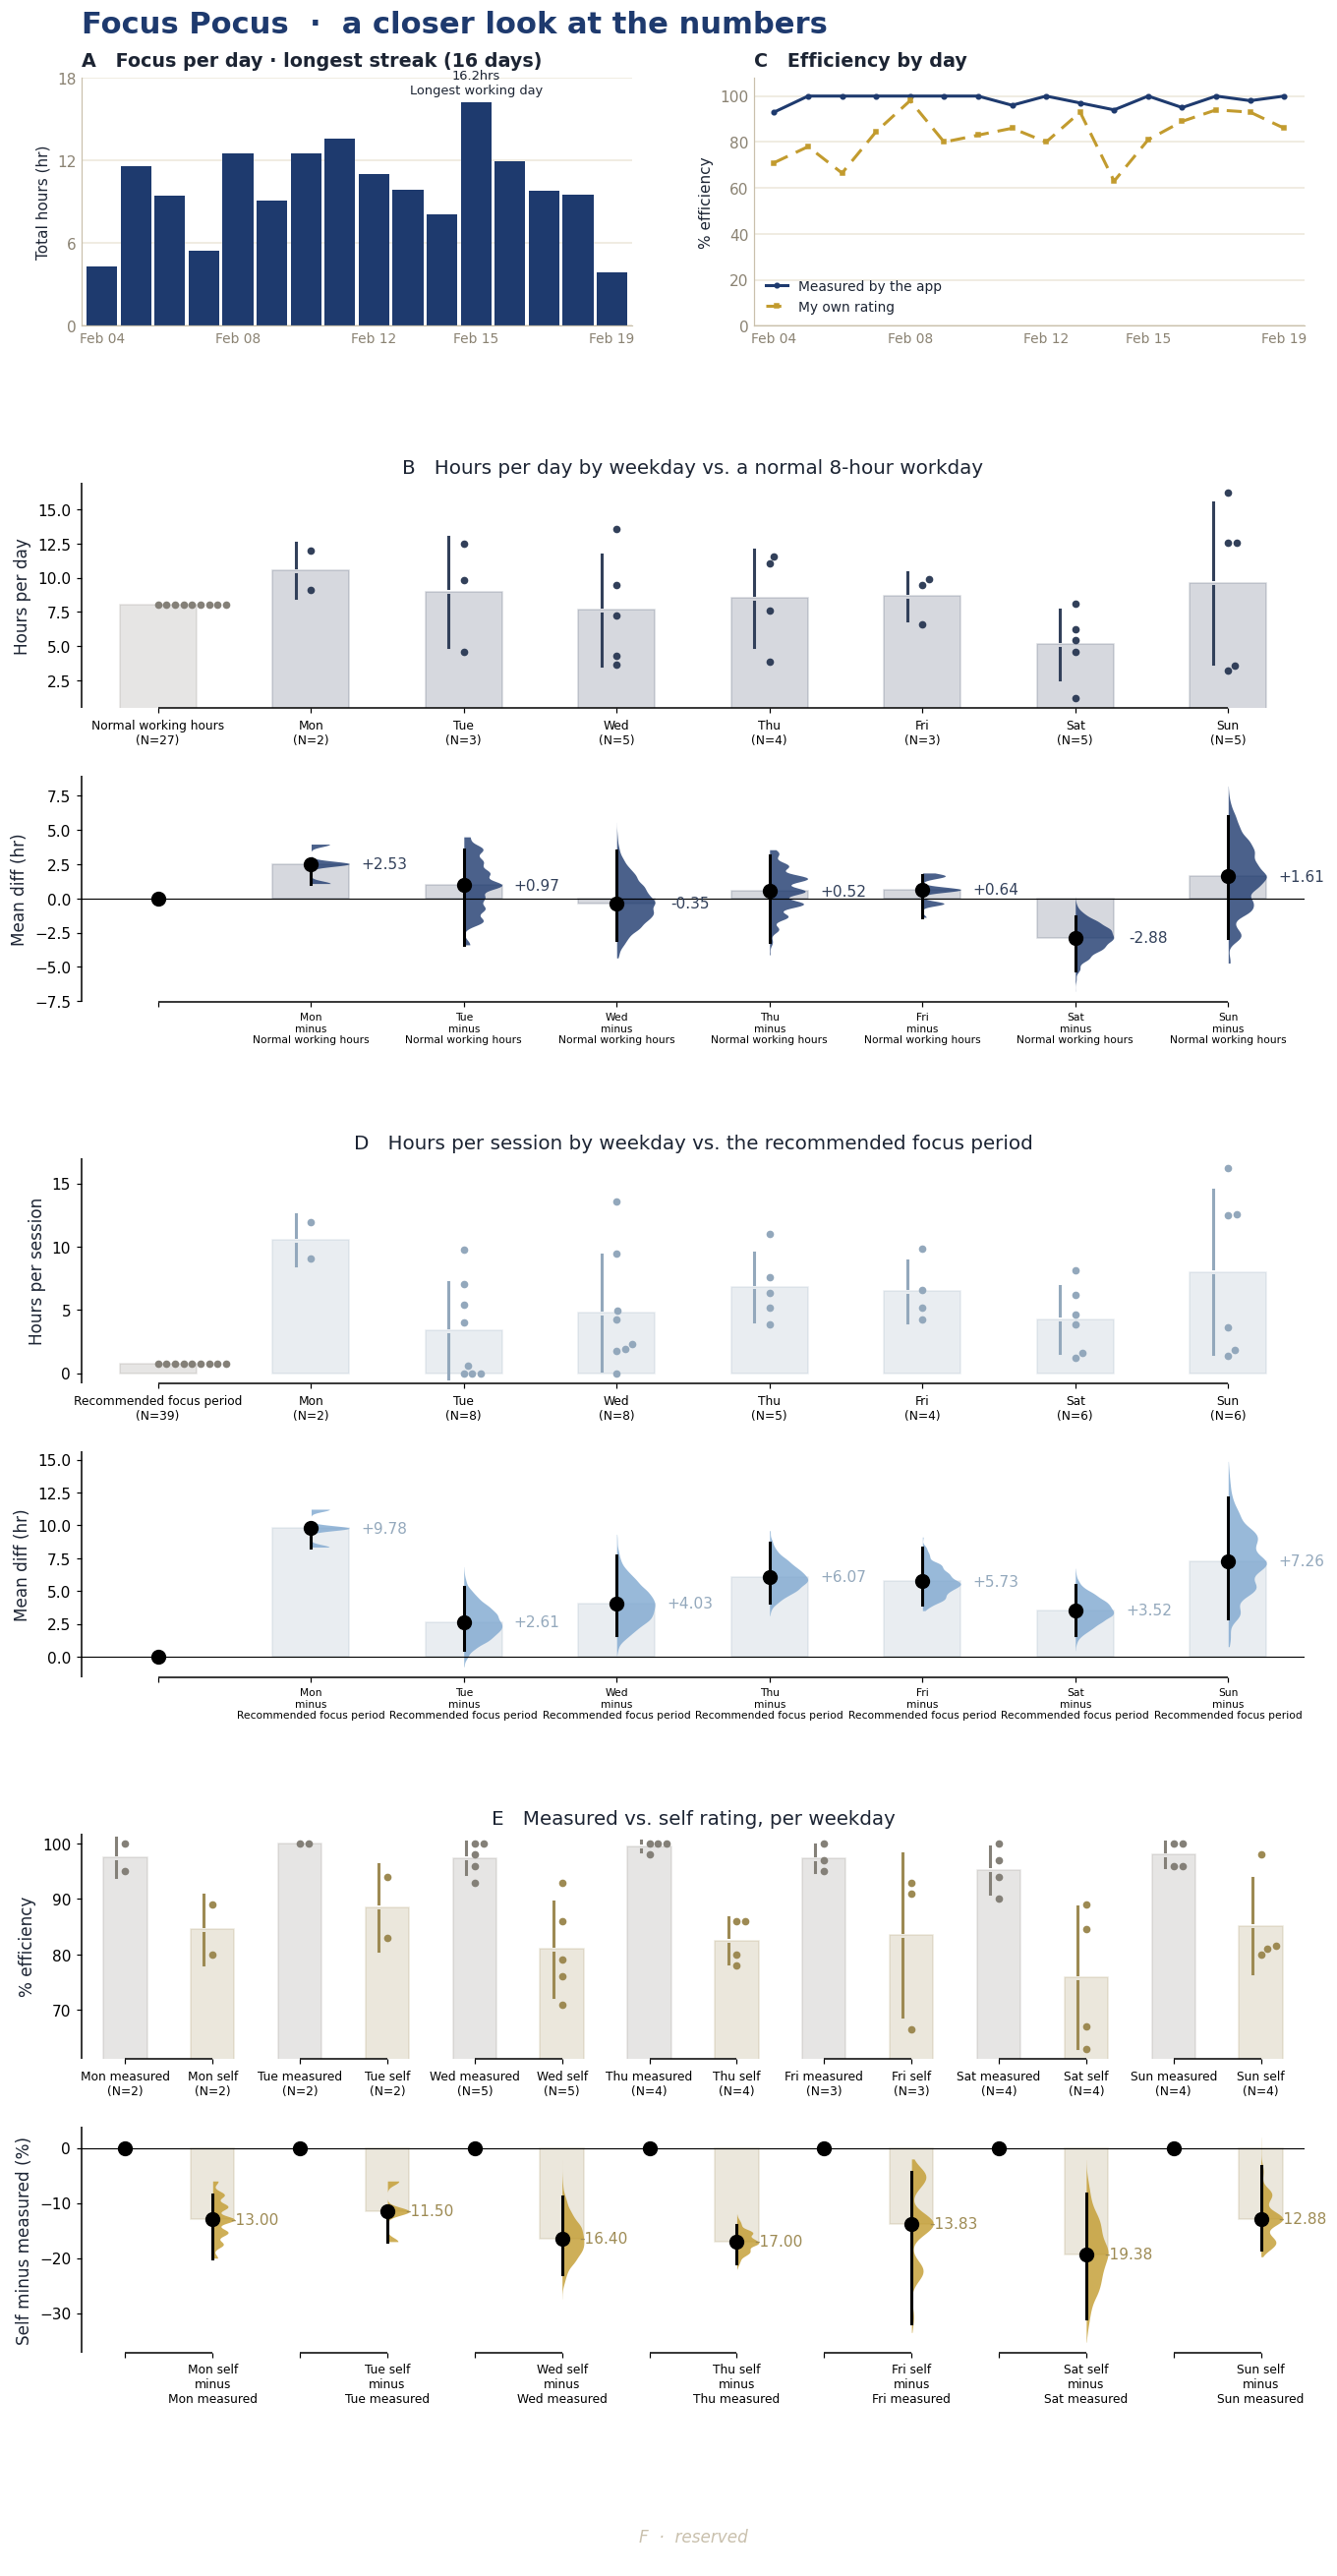

In [4]:
fig=plt.figure(figsize=(13,25),dpi=110); fig.patch.set_facecolor(BG)
gs=fig.add_gridspec(5,2,height_ratios=[1.1,2.3,2.3,2.3,0.25],hspace=0.42,wspace=0.22,
                    left=0.08,right=0.95,top=0.95,bottom=0.03)
fig.suptitle("Focus Pocus  ·  a closer look at the numbers",color=NAVY,fontsize=20,
             fontweight="bold",x=0.08,ha="left",y=0.975)

# A
axA=fig.add_subplot(gs[0,0]); clean(axA)
xs=np.arange(len(streak)); sh=day_hours[streak]
axA.bar(xs,sh,width=0.9,color=NAVY,lw=0,zorder=2)
axA.set_xlim(-0.6,len(xs)-0.4); axA.set_ylim(0,18); axA.set_ylabel("Total hours (hr)")
tk=np.unique(np.linspace(0,len(xs)-1,5).round().astype(int))
axA.set_xticks(tk); axA.set_xticklabels([day_dt[streak[i]].strftime("%b %d") for i in tk],fontsize=9)
axA.set_yticks([0,6,12,18]); axA.set_title(f"A   Focus per day · longest streak ({len(xs)} days)",
    loc="left",fontsize=12.5,fontweight="bold",color=INK,pad=8)
pk=int(np.argmax(sh))
axA.annotate(f"{sh[pk]:.1f}hrs\nLongest working day",xy=(pk,sh[pk]),xytext=(pk,sh[pk]+0.4),
             ha="center",va="bottom",fontsize=8.5,color=INK,linespacing=1.2)

# C  (same date range as A: the longest streak)
axC=fig.add_subplot(gs[0,1]); clean(axC)
byday=L.groupby("date").agg(meas=("meas_eff","mean"),selfe=("self_eff","mean")).reindex(days)
sc=byday.iloc[streak]
xs=np.arange(len(streak))
axC.plot(xs,sc["meas"].to_numpy(),color=NAVY,lw=2,marker="o",ms=3,label="Measured by the app",zorder=3)
axC.plot(xs,sc["selfe"].to_numpy(),color=GOLD,lw=2,ls=(0,(5,3)),marker="s",ms=3,label="My own rating",zorder=3)
axC.set_xlim(-0.6,len(xs)-0.4)
axC.set_ylim(0,108); axC.set_yticks([0,20,40,60,80,100]); axC.set_ylabel("% efficiency")
tk=np.unique(np.linspace(0,len(xs)-1,5).round().astype(int))
axC.set_xticks(tk); axC.set_xticklabels([day_dt[streak[i]].strftime("%b %d") for i in tk],fontsize=9)
axC.legend(loc="lower left",frameon=False,fontsize=9,handlelength=1.6)
axC.set_title("C   Efficiency by day",loc="left",fontsize=12.5,fontweight="bold",color=INK,pad=8)

# B: hours per day by weekday vs 8h
axB=fig.add_subplot(gs[1,:])
bframe=pd.DataFrame({"g":df["day"],"y":df["day_hours"]})
dabest_panel(axB,"Normal working hours",[8.0]*len(df),"g","y",bframe,NAVY,
             "Hours per day","Mean diff (hr)",
             "B   Hours per day by weekday vs. a normal 8-hour workday")

# D: hours per session by weekday vs 45-min block
axD=fig.add_subplot(gs[2,:])
dframe=L[["day","focus_hours"]].rename(columns={"focus_hours":"y","day":"g"})
dabest_panel(axD,"Recommended focus period",[POMODORO_H]*len(L),"g","y",dframe,PBLUE,
             "Hours per session","Mean diff (hr)",
             "D   Hours per session by weekday vs. the recommended focus period")

# E: each weekday's measured vs self rating (per-day)
axE=fig.add_subplot(gs[3,:])
eday=L.dropna(subset=["self_eff"]).groupby(["date","day"]).agg(
        meas=("meas_eff","mean"),selfe=("self_eff","mean")).reset_index()
epres=[w for w in WK if (eday["day"]==w).any()]
erows=[]
for w in epres:
    sub=eday[eday["day"]==w]
    erows+=[(f"{w} measured",v) for v in sub["meas"]]+[(f"{w} self",v) for v in sub["selfe"]]
elong=pd.DataFrame(erows,columns=["g","y"])
eidx=tuple((f"{w} measured",f"{w} self") for w in epres)
edb=dabest.load(elong, idx=eidx, x="g", y="y")
epal={}
for w in epres: epal[f"{w} measured"]=MUTED; epal[f"{w} self"]=GOLD
edb.mean_diff.plot(ax=axE, raw_marker_size=4, custom_palette=epal,
                   raw_label="% efficiency", contrast_label="Self minus measured (%)",
                   title="E   Measured vs. self rating, per weekday", fontsize_title=13,
                   fontsize_rawylabel=11, fontsize_contrastylabel=11,
                   fontsize_rawxlabel=8, fontsize_contrastxlabel=8)

# F
axF=fig.add_subplot(gs[4,:]); axF.axis("off")
axF.text(0.5,0.5,"F  ·  reserved",ha="center",va="center",color=AXISC,fontsize=11,style="italic")

fig.savefig(os.path.join(HERE,"stats-dashboard-DRAFT.png"),dpi=130,facecolor=BG,bbox_inches="tight",pad_inches=0.3)
plt.show()